Enter the grid size N (e.g., 5):  5


Generating an 5x5 log-scaled snaking staircase...

Success! Saved interactive 3D plot to: Fibonacci_Staircase_Log_N5.html


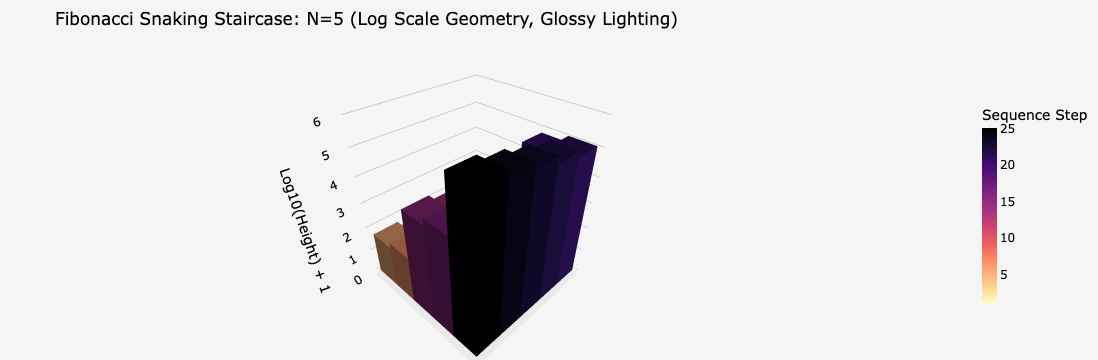

In [13]:
import numpy as np
import plotly.graph_objects as go
import sys

def generate_fibonacci(count):
    """Generates the first 'count' Fibonacci numbers using float64 to delay overflow."""
    fibs = np.zeros(count, dtype=np.float64)
    if count > 0: fibs[0] = 1
    if count > 1: fibs[1] = 1
    for i in range(2, count):
        fibs[i] = fibs[i-1] + fibs[i-2]
    return fibs

def create_snaking_grids(N):
    """
    Returns TWO grids:
    1. h_grid: The actual Fibonacci heights.
    2. color_grid: The sequence index (1 to N^2) for a perfectly even color gradient.
    """
    total_numbers = N**2
    fibs = generate_fibonacci(total_numbers)
    h_grid = np.zeros((N, N), dtype=np.float64)
    color_grid = np.zeros((N, N), dtype=np.float64)
    
    idx = 0
    # Loop from bottom row (y=0) to top row (y=N-1)
    for y in range(N):
        if y % 2 == 0:
            # Even rows: Left to right
            for x in range(N):
                h_grid[y, x] = fibs[idx]
                color_grid[y, x] = idx + 1 # Step index starts at 1
                idx += 1
        else:
            # Odd rows: Right to left
            for x in range(N-1, -1, -1):
                h_grid[y, x] = fibs[idx]
                color_grid[y, x] = idx + 1
                idx += 1
                
    return h_grid, color_grid

def build_voxel_mesh(h, c):
    """
    Constructs a 3D blocky mesh. Geometry is log-scaled from 'h', color comes from 'c'.
    """
    N = h.shape[0]
    vertices = []
    i_faces, j_faces, k_faces = [], [], []
    vertex_colors = []
    
    v_idx = 0
    for y in range(N):
        for x in range(N):
            H = h[y, x]
            C = c[y, x] # Fetch the perfectly uniform sequence index
            
            # Define block boundaries
            x0, x1 = x - 0.5, x + 0.5
            y0, y1 = y - 0.5, y + 0.5
            
            # MATH BRILLIANCE: Log scale the geometry! 
            # We add 1 so that F_n=1 doesn't have a height of 0.
            z0 = 0
            z1 = np.log10(H) + 1 if H > 0 else 0
            
            # 8 vertices of the cube/step
            box_verts = [
                [x0, y0, z0], [x1, y0, z0], [x1, y1, z0], [x0, y1, z0], # Bottom 4
                [x0, y0, z1], [x1, y0, z1], [x1, y1, z1], [x0, y1, z1]  # Top 4
            ]
            vertices.extend(box_verts)
            
            # Apply the sequence index value to all 8 vertices of this block
            vertex_colors.extend([C] * 8)
            
            # 12 triangles (2 per face of the cube)
            faces = [
                [0, 1, 2], [0, 2, 3], # Bottom
                [4, 5, 6], [4, 6, 7], # Top
                [0, 1, 5], [0, 5, 4], # Front
                [2, 3, 7], [2, 7, 6], # Back
                [0, 3, 7], [0, 7, 4], # Left
                [1, 2, 6], [1, 6, 5]  # Right
            ]
            
            for tri in faces:
                i_faces.append(tri[0] + v_idx)
                j_faces.append(tri[1] + v_idx)
                k_faces.append(tri[2] + v_idx)
                
            v_idx += 8
            
    vx, vy, vz = zip(*vertices)
    return vx, vy, vz, i_faces, j_faces, k_faces, vertex_colors

def plot_interactive_staircase(N):
    """Renders the grid into an interactive Plotly HTML."""
    
    # Generate both grids
    h_grid, c_grid = create_snaking_grids(N)
    vx, vy, vz, i_faces, j_faces, k_faces, vertex_colors = build_voxel_mesh(h_grid, c_grid)

    mesh = go.Mesh3d(
        x=vx, y=vy, z=vz,
        i=i_faces, j=j_faces, k=k_faces,
        intensity=vertex_colors,
        colorscale='Magma_r',     
        intensitymode='vertex',
        flatshading=True,         
        showscale=True,
        colorbar=dict(
            title=dict(text="Sequence Step", font=dict(color="black")), 
            thickness=15, 
            len=0.7, 
            tickfont=dict(color="black") 
        ),
        # SHIMMER EFFECT: High specular, low roughness, plus fresnel
        lighting=dict(
            ambient=0.4, 
            diffuse=0.8, 
            specular=1.5, 
            roughness=0.1, 
            fresnel=0.2
        )
    )
    
    fig = go.Figure(data=[mesh])
    
    fig.update_layout(
        title=f"Fibonacci Snaking Staircase: N={N} (Log Scale Geometry, Glossy Lighting)",
        scene=dict(
            xaxis=dict(title="X", visible=False),
            yaxis=dict(title="Y", visible=False),
            zaxis=dict(title="Log10(Height) + 1", backgroundcolor='#EAEAEA', gridcolor='#CCCCCC'),
            # We unconstrain the Z aspect ratio slightly so the linear staircase can stretch naturally
            aspectmode='auto'
        ),
        margin=dict(l=0, r=0, b=0, t=50),
        paper_bgcolor='#F5F5F5', 
        font=dict(color='black') 
    )
    
    filename = f"Fibonacci_Staircase_Log_N{N}.html"
    fig.write_html(filename)
    print(f"\nSuccess! Saved interactive 3D plot to: {filename}")
    
    try:
        get_ipython()
        fig.show()
    except NameError:
        pass

# --- INTERACTIVE EXECUTION ---
if __name__ == "__main__":
    raw_input = input("Enter the grid size N (e.g., 5): ")
    
    try:
        clean_input = raw_input.strip().strip('"').strip("'")
        N = int(float(clean_input))
        
        if N <= 0:
            print("Please enter a positive integer.")
        elif N > 30:
            print(f"Warning: N={N} requires calculating Fibonacci numbers up to index {N**2}.")
            print("This exceeds standard float limitations. Capping N at 30.")
            N = 30
        else:    
            print(f"Generating an {N}x{N} log-scaled snaking staircase...")
            plot_interactive_staircase(N)
            
    except ValueError as e:
        print(f"System Error: {e}")
        print("Python could not recognize that input as a number.")

In [14]:
import streamlit as st
import numpy as np
import plotly.graph_objects as go

def generate_fibonacci(count):
    """Generates the first 'count' Fibonacci numbers using float64 to delay overflow."""
    fibs = np.zeros(count, dtype=np.float64)
    if count > 0: fibs[0] = 1
    if count > 1: fibs[1] = 1
    for i in range(2, count):
        fibs[i] = fibs[i-1] + fibs[i-2]
    return fibs

def create_snaking_grids(N):
    """Returns the Fibonacci heights and the sequence index for the even color gradient."""
    total_numbers = N**2
    fibs = generate_fibonacci(total_numbers)
    h_grid = np.zeros((N, N), dtype=np.float64)
    color_grid = np.zeros((N, N), dtype=np.float64)
    
    idx = 0
    for y in range(N):
        if y % 2 == 0:
            for x in range(N):
                h_grid[y, x] = fibs[idx]
                color_grid[y, x] = idx + 1
                idx += 1
        else:
            for x in range(N-1, -1, -1):
                h_grid[y, x] = fibs[idx]
                color_grid[y, x] = idx + 1
                idx += 1
    return h_grid, color_grid

def build_voxel_mesh(h, c, use_log):
    """Constructs the 3D blocky mesh based on whether log-scale is toggled."""
    N = h.shape[0]
    vertices = []
    i_faces, j_faces, k_faces = [], [], []
    vertex_colors = []
    
    v_idx = 0
    for y in range(N):
        for x in range(N):
            H = h[y, x]
            C = c[y, x] 
            
            x0, x1 = x - 0.5, x + 0.5
            y0, y1 = y - 0.5, y + 0.5
            
            z0 = 0
            # Apply log scale to geometry if the student checked the box
            if use_log:
                z1 = np.log10(H) + 1 if H > 0 else 0
            else:
                z1 = H
            
            box_verts = [
                [x0, y0, z0], [x1, y0, z0], [x1, y1, z0], [x0, y1, z0], 
                [x0, y0, z1], [x1, y0, z1], [x1, y1, z1], [x0, y1, z1]  
            ]
            vertices.extend(box_verts)
            vertex_colors.extend([C] * 8)
            
            faces = [
                [0, 1, 2], [0, 2, 3], [4, 5, 6], [4, 6, 7], 
                [0, 1, 5], [0, 5, 4], [2, 3, 7], [2, 7, 6], 
                [0, 3, 7], [0, 7, 4], [1, 2, 6], [1, 6, 5]  
            ]
            
            for tri in faces:
                i_faces.append(tri[0] + v_idx)
                j_faces.append(tri[1] + v_idx)
                k_faces.append(tri[2] + v_idx)
                
            v_idx += 8
            
    # Handle empty grids safely
    if not vertices:
        return [], [], [], [], [], [], []
        
    vx, vy, vz = zip(*vertices)
    return vx, vy, vz, i_faces, j_faces, k_faces, vertex_colors

# ==========================================
# STREAMLIT APPLET UI
# ==========================================

# Configure the webpage appearance
st.set_page_config(page_title="Fibonacci Staircase Explorer", layout="centered")

st.title("Fibonacci 3D Staircase Explorer")

# 1) Applet Input: N
N = st.number_input(
    "Choose N, and I will show you the first N^2 Fibonacci numbers", 
    min_value=1, 
    max_value=12,  # Capped at 12 to prevent the browser from lagging on massive meshes
    value=5, 
    step=1
)

# 2) Applet Input: Log-Scale Toggle
use_log = st.checkbox("Plot using Log-Scale (Linear Staircase)")

st.divider() # Visual separator

# Generate the data based on inputs
h_grid, c_grid = create_snaking_grids(N)
vx, vy, vz, i_faces, j_faces, k_faces, vertex_colors = build_voxel_mesh(h_grid, c_grid, use_log)

# Conditionally set styling based on the student's toggle choice
if use_log:
    colorscale = 'Blues'  # Cool blue monochromatic gradient
    z_title = "Log10(Height) + 1"
    plot_title = f"Log-Scale Fibonacci Staircase (N={N})"
    aspect_mode = 'auto' # Let the linear staircase stretch naturally
    aspect_ratio = None
else:
    colorscale = 'Plasma' # Vibrant, multi-color gradient
    z_title = "True Height"
    plot_title = f"True-Height Fibonacci Staircase (N={N})"
    aspect_mode = 'manual'
    aspect_ratio = dict(x=1, y=1, z=0.6) # Constrain the massive true heights

# Build the 3D Plotly figure
mesh = go.Mesh3d(
    x=vx, y=vy, z=vz,
    i=i_faces, j=j_faces, k=k_faces,
    intensity=vertex_colors,
    colorscale=colorscale,     
    intensitymode='vertex',
    flatshading=True,         
    showscale=True,
    colorbar=dict(
        title=dict(text="Sequence Step", font=dict(color="black")), 
        thickness=15, 
        len=0.7, 
        tickfont=dict(color="black") 
    ),
    # Glossy lighting effect
    lighting=dict(ambient=0.4, diffuse=0.8, specular=1.5, roughness=0.1, fresnel=0.2)
)

fig = go.Figure(data=[mesh])

fig.update_layout(
    title=plot_title,
    scene=dict(
        xaxis=dict(title="X", visible=False),
        yaxis=dict(title="Y", visible=False),
        zaxis=dict(title=z_title, backgroundcolor='#EAEAEA', gridcolor='#CCCCCC'),
        aspectmode=aspect_mode,
        aspectratio=aspect_ratio
    ),
    margin=dict(l=0, r=0, b=0, t=50),
    paper_bgcolor='#F5F5F5', 
    font=dict(color='black'),
    height=600 # Force the plot to take up a nice chunk of the screen
)

# Render the Plotly figure inside the Streamlit app
st.plotly_chart(fig, use_container_width=True)

2026-04-20 15:53:58.592 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-20 15:53:58.592 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-20 15:53:58.715 
  command:

    streamlit run /Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-04-20 15:53:58.716 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-20 15:53:58.716 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-20 15:53:58.717 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-20 15:53:58.717 Thread 'MainThread': missing ScriptRunContext! Th

DeltaGenerator()